In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")
veri = pd.read_csv("olimpiyatlar_madalya_alanlar.csv")


In [2]:
erkek= veri[veri.cinsiyet == "M"]
kadin= veri[veri.cinsiyet == "F"]
erkek.head(5)

,isim,cinsiyet,yas,boy,kilo,takim,kod,yil,sezon,sehir,spor,etkinlik,madalya
0,Edgar Lindenau Aabye,M,34.0,182.48,95.62,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
1,Arvo Ossian Aaltonen,M,30.0,182.01,76.69,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
2,Arvo Ossian Aaltonen,M,30.0,177.00,75.00,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
3,Juhamatti Tapio Aaltonen,M,28.0,184.00,85.00,Finland,FIN,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
4,Paavo Johannes Aaltonen,M,28.0,175.00,64.00,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


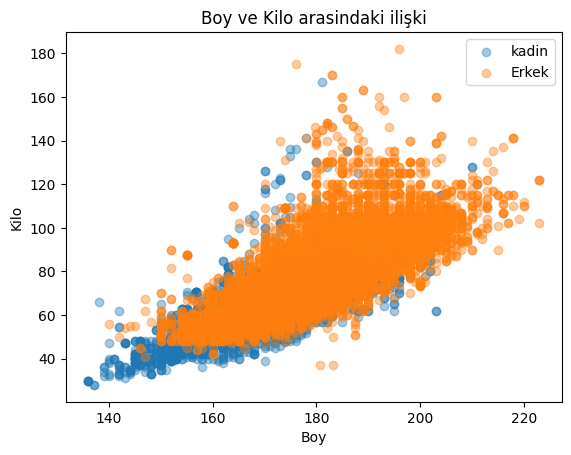

In [3]:
plt.figure()
plt.scatter(kadin.boy, kadin.kilo, alpha=0.4 ,label= "kadin") #alpha= saydamlık
plt.scatter(erkek.boy, erkek.kilo, alpha=0.4, label= "Erkek")
plt.xlabel("Boy")
plt.ylabel("Kilo")
plt.title("Boy ve Kilo arasindaki ilişki")
plt.legend()
plt.show()

In [4]:
veri.loc[:, ["yas", "boy", "kilo"]].corr()
# boy ve kilo arasında pozitif kolarizasyon var şuanki database e göre!
# bu kod bloğuna göre kolarizasyon  var mı yok mu görebiliriz.

,yas,boy,kilo
yas,1.000000,0.061890,0.136349
boy,0.061890,1.000000,0.794368
kilo,0.136349,0.794368,1.000000


In [5]:
#Anomali tespiti!
from collections import Counter
def anomaliTespiti(df, ozellik):
    outlier_indices=[]
    for c in ozellik:
        Q1= np.percentile(df[c], 25) #yasa göre dağışımdaki %25lik kısmı alıcak
        #print(Q1)
        Q3= np.percentile(df[c], 75)
        IQR = Q3-Q1 #orta %50’lik verinin genişliği
        outlier_step= IQR*1.5 #anomali kuralı.
        #Yani veri noktası şu aralığın dışındaysa anomali sayılır
        outlier_list_col= df[ (df[c]<Q1- outlier_step) | (df[c]> Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list_col) #genel listeye ekler.
        
    outlier_indices= Counter(outlier_indices) #kaç kez aykırı olduğunu sayar.
    multiple_outlier= list(i for i,v in outlier_indices.items() if v>0)
    return multiple_outlier
ozellikler = ["yas", "boy", "kilo"]
indices=anomaliTespiti(veri, ozellikler)
veri_anomali= veri.loc[anomaliTespiti(veri, ozellikler)]
veri_anomali.spor.value_counts()

spor
Equestrianism           286
Shooting                268
Sailing                 209
Basketball              160
Athletics               159
Gymnastics              123
Fencing                 119
Wrestling                90
Art Competitions         84
Weightlifting            82
Archery                  78
Judo                     70
Rowing                   44
Bobsleigh                34
Volleyball               31
Water Polo               27
Handball                 26
Curling                  26
Polo                     15
Canoeing                 13
Tennis                    8
Cycling                   8
Swimming                  8
Alpinism                  7
Ice Hockey                7
Figure Skating            7
Diving                    7
Golf                      6
Tug-Of-War                5
Boxing                    5
Baseball                  5
Luge                      4
Hockey                    3
Biathlon                  3
Cross Country Skiing      3
Cricket        

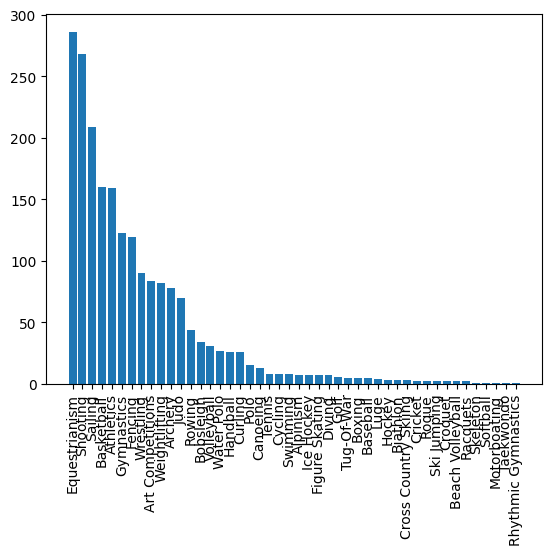

In [6]:
plt.figure()
plt.bar(veri_anomali.spor.value_counts().index , veri_anomali.spor.value_counts().values)
plt.xticks(rotation=90)
plt.show()

In [7]:
veri_gym = veri_anomali[veri_anomali.spor=="Basketball"]
veri_gym

,isim,cinsiyet,yas,boy,kilo,takim,kod,yil,sezon,sehir,spor,etkinlik,madalya
890,Vladimir Georgiyevich Andreyev,M,23.0,215.0,90.0,Soviet Union,URS,1968,Summer,Mexico City,Basketball,Basketball Men's Basketball,Bronze
1086,Franjo Arapovi,M,23.0,211.0,120.0,Yugoslavia,YUG,1988,Summer,Seoul,Basketball,Basketball Men's Basketball,Silver
1087,Franjo Arapovi,M,27.0,211.0,120.0,Croatia,CRO,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,Silver
1631,"Vincent Lamont ""Vin"" Baker",M,28.0,207.0,109.0,United States,USA,2000,Summer,Sydney,Basketball,Basketball Men's Basketball,Gold
2376,"Walter Jones ""Walt"" Bellamy, Jr.",M,23.0,211.0,98.0,United States,USA,1960,Summer,Roma,Basketball,Basketball Men's Basketball,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30062,Romeo Sacchetti,M,26.0,196.0,110.0,Italy,ITA,1980,Summer,Moskva,Basketball,Basketball Men's Basketball,Silver
32705,Darius Songaila,M,22.0,204.0,110.0,Lithuania,LTU,2000,Summer,Sydney,Basketball,Basketball Men's Basketball,Bronze
35030,Wayman Lawrence Tisdale,M,20.0,205.0,118.0,United States,USA,1984,Summer,Los Angeles,Basketball,Basketball Men's Basketball,Gold
39501,Zheng Haixia,F,17.0,204.0,115.0,China,CHN,1984,Summer,Los Angeles,Basketball,Basketball Women's Basketball,Bronze
